**Diana Itzel Soto Castañeda**

**Ciencia de Datos para Sensores Inteligentes**

## Imports

In [73]:
# system libraries
import os
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.9.13 (tags/v3.9.13:6de2ca5, May 17 2022, 16:36:42) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Diana\git\Course_CDSI_2026\practicas\PR1_Reconocimiento_Audio\.venv\Scripts\python.exe


Nota: Los entornos virtuales (.venv) no se encuentran en el repositorio de GitHub.

In [74]:
# data 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# audio
import IPython.display as ipd
from IPython.display import Audio, display, Markdown
import librosa
import librosa.display

# warnings (opional)
#import warnings
#if not sys.warnoptions:
#    warnings.simplefilter("ignore")
#warnings.filterwarnings("ignore", category=DeprecationWarning)

# Practica 1 — Reconocimiento de ADLs con audio


## Introducción

En esta práctica se aborda el reconocimiento de *Activities of Daily Living (ADLs)* utilizando señales de audio como fuente principal de información, el objetivo es el de identificar las siguientes actividades:
- Bajarle al WC (Bano)
- Lavar platos (Cocina)
- Conversación (Sala)
- Música de fondo (Oficina)
- Pasos al caminar (Múltiples lugares) [Pasos]
- Otros sonidos (Nula)

El desarrollo de la práctica sigue el siguiente flujo: Recolección y organización de datos, preprocesamiento de las señales de audio, extracción y selección de características relevantes, y finalmente la construcción y evaluación de modelos de clasificación

## Objetivo

El objetivo principal de esta práctica es aplicar técnicas de análisis de datos y aprendizaje automático para entrenar modelos capaces de reconocer automáticamente distintas actividades a partir de audio, así como evaluar su desempeño mediante métricas típicas.

## Desarrollo

Definición de etiquetas

In [76]:
## Definición de etiquetas válidas
Etiquetas_validas = {
    "BANO", "COCINA", "NULA",
    "OFICINA", "PASOS", "SALA"
}

### Recolección de audios y conformación del dataset

Los datos recolectados se encuentran en la carpeta Data de esta carpeta de proyecto. Los audios tiene una duración de 10 segundos y se recolectaron de manera colectiva.

### Procesamiento de los audios

In [52]:
#!pip install librosa

Carga de datos

In [53]:
Data = "data"
os.listdir(Data)

['Diana Itzel',
 'Ian Svén',
 'Javier R',
 'José Juárez',
 'Norman O',
 'Zarif León']

In [54]:
dirl_list = os.listdir(Data)
print(dirl_list)

for estudiante in dirl_list:
    path_estudiante = os.path.join(Data, estudiante)
    print(f"\n📁 {estudiante}")
    print(os.listdir(path_estudiante))

['Diana Itzel', 'Ian Svén', 'Javier R', 'José Juárez', 'Norman O', 'Zarif León']

📁 Diana Itzel
['DISC_BANO_01.wav', 'DISC_BANO_02.wav', 'DISC_BANO_03.wav', 'DISC_COCINA_01.wav', 'DISC_COCINA_02.wav', 'DISC_COCINA_03.wav', 'DISC_NULA_01.wav', 'DISC_NULA_02.wav', 'DISC_NULA_03.wav', 'DISC_OFICINA_01.wav', 'DISC_OFICINA_02.wav', 'DISC_OFICINA_03.wav', 'DISC_PASOS_01.wav', 'DISC_PASOS_02.wav', 'DISC_PASOS_03.wav', 'DISC_SALA_01.wav', 'DISC_SALA_02.wav', 'DISC_SALA_03.wav']

📁 Ian Svén
[]

📁 Javier R
['JR_bano_01.wav', 'JR_bano_02.wav', 'JR_bano_03.wav', 'JR_cocina_01.wav', 'JR_cocina_02.wav', 'JR_cocina_03.wav', 'JR_nula_01.wav', 'JR_nula_02.wav', 'JR_nula_03.wav', 'JR_oficina_01.wav', 'JR_oficina_02.wav', 'JR_oficina_03.wav', 'JR_pasos_01.wav', 'JR_pasos_02.wav', 'JR_pasos_03.wav', 'JR_sala_01.wav', 'JR_sala_02.wav', 'JR_sala_03.wav']

📁 José Juárez
['JFJA_BANO_01.wav', 'JFJA_BANO_02.wav', 'JFJA_BANO_03.wav', 'JFJA_COCINA_01.wav', 'JFJA_COCINA_02.wav', 'JFJA_COCINA_03.wav', 'JFJA_NULA_01

In [55]:
# Construcción del DataFrame
data = []

for estudiante in dirl_list:
    path_estudiante = os.path.join(Data, estudiante)

    if not os.path.isdir(path_estudiante):
        continue

    archivos = os.listdir(path_estudiante)
    if len(archivos) == 0:
        print(f"Carpeta vacía: {estudiante}")
        continue

    for archivo in archivos:
        if not archivo.lower().endswith(".wav"):
            continue

        # Extraer etiqueta del nombre del archivo
        nombre = archivo.replace(".wav", "")
        partes = nombre.split("_")

        if len(partes) < 2:
            print(f"Archivo ignorado (formato inválido): {archivo}")
            continue

        label = partes[1].upper()

        # Unificar NULO y NULA
        if label == "NULO":
            label = "NULA"

        if label not in Etiquetas_validas:
            print(f"Archivo ignorado (etiqueta inválida): {archivo}")
            continue

        path_archivo = os.path.join(path_estudiante, archivo)
        y, sr = librosa.load(path_archivo, sr=None)

        data.append({
            "estudiante": estudiante,
            "archivo": archivo,
            "etiqueta": label,
            "senal": y,
            "sr": sr
        })

CDSI2026_df = pd.DataFrame(data)
CDSI2026_df.etiqueta.value_counts()

Carpeta vacía: Ian Svén


etiqueta
BANO       15
COCINA     15
NULA       15
OFICINA    15
PASOS      15
SALA       15
Name: count, dtype: int64

Exploración de datos

Previo al preprocesamiento, se realizó una inspección exploratoria básica una señal de audio aleatoria mediante la reproducción y visualización de formas de onda y espectrogramas.

In [56]:
# Escucha de una muestra aleatoria
row = CDSI2026_df.sample(1).iloc[0]
print("Actividad:", row["etiqueta"])
display(Audio(row["senal"], rate=row["sr"]))

Actividad: BANO


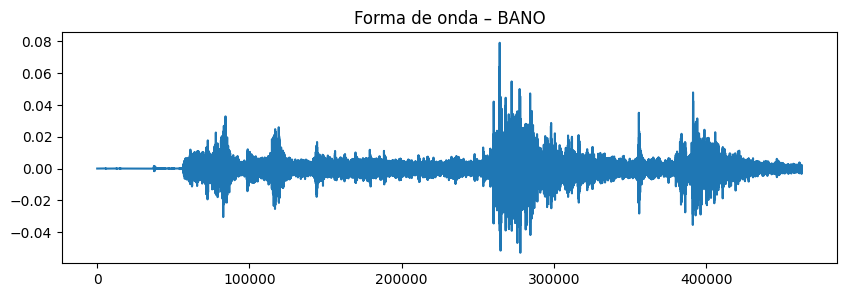

In [57]:
# Visualización de la forma de onda
plt.figure(figsize=(10,3))
plt.plot(row["senal"])
plt.title(f"Forma de onda – {row['etiqueta']}")
plt.show()


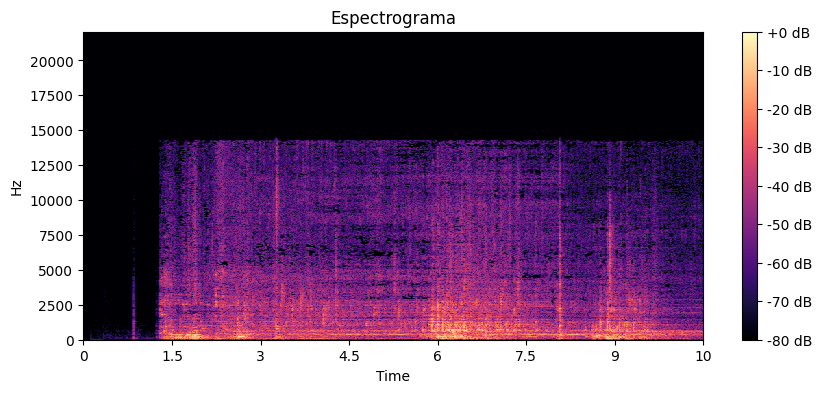

In [58]:
# Espectrograma
S = librosa.stft(row["senal"])
S_db = librosa.amplitude_to_db(abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(S_db, sr=row["sr"], x_axis="time", y_axis="hz")
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma")
plt.show()


Se identificó la presencia de ruido de fondo aproximadamente estacionario.

#### Aplicar una función para eliminar ruidos estacionarios de fondo

Aplicar la función eliminar_ruido_estacionario y generar una nueva columna con datos de la señal sin ruido

In [64]:
def aplicar_eliminacion_ruido(senal, sr, percentil_ruido=10):
    """Elimina ruido estacionario de una señal de audio"""
    S = librosa.stft(senal)
    magnitud, fase = librosa.magphase(S)
    perfil_ruido = np.percentile(magnitud, percentil_ruido, axis=1, keepdims=True)
    magnitud_limpia = np.maximum(magnitud - perfil_ruido, 0)
    S_limpia = magnitud_limpia * fase
    senal_sinruido = librosa.istft(S_limpia)
    return senal_sinruido

CDSI2026_df["senal_sin_ruido"] = CDSI2026_df.apply(
    lambda row: aplicar_eliminacion_ruido(row["senal"], row["sr"]),
    axis=1
)

Comparar Espectrogramas

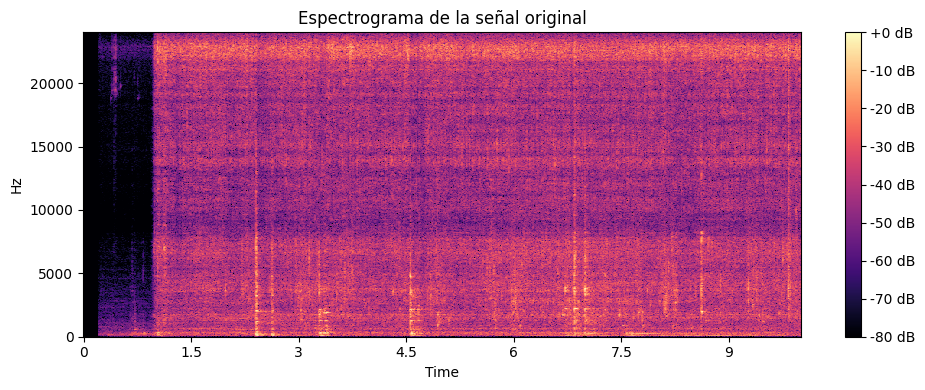

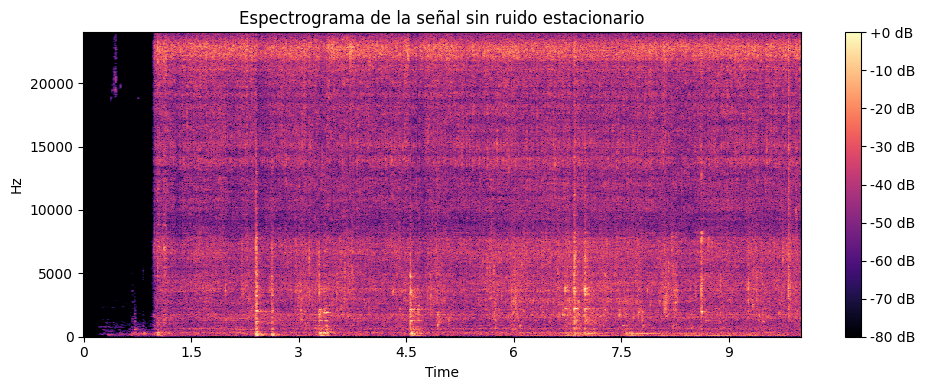

In [65]:
# Obtener una nueva muestra con los datos procesados
row = CDSI2026_df.sample(1).iloc[0]

# STFT - Señal original
S = librosa.stft(row["senal"])

# Convertir a decibeles
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

# Graficar espectrograma
plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=row["sr"],
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma de la señal original")
plt.tight_layout()
plt.show()

# STFT - Señal sin ruido
S = librosa.stft(row["senal_sin_ruido"])
S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

plt.figure(figsize=(10,4))
librosa.display.specshow(
    S_db,
    sr=row["sr"],
    x_axis="time",
    y_axis="hz"
)
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma de la señal sin ruido estacionario")
plt.tight_layout()
plt.show()

In [66]:
print("Original")
display(Audio(row["senal"], rate=row["sr"]))

print("Sin ruido estacionario")
display(Audio(row["senal_sin_ruido"], rate=row["sr"]))

Original


Sin ruido estacionario


Aunque la diferencia perceptual entre la señal original y la señal procesada es sutil, el análisis en el dominio de la frecuencia mediante espectrogramas permitió identificar, en algunos casos específicos, una reducción de componentes asociadas al ruido estacionario de fondo. 

#### Aplicar una función de normalización para asegurar un volumen constante y evitar sesgos

In [70]:
CDSI2026_df["senal_normalizada"] = CDSI2026_df["senal_sin_ruido"].apply(
    lambda s: librosa.util.normalize(s)
)

# Verificación de la normalización
row = CDSI2026_df.sample(1).iloc[0]

print("Máx normalizada:", np.max(np.abs(row["senal_normalizada"])))

Máx normalizada: 1.0


### Extracción y selección de características

#### MFCC

In [78]:
mfccs = []

for _, row in CDSI2026_df.iterrows():
    mfcc = librosa.feature.mfcc(
        y=row["senal_normalizada"],
        sr=row["sr"],
        n_mfcc=13
    )
    mfccs.append(np.mean(mfcc, axis=1))

mfcc_df = pd.DataFrame(
    mfccs,
    columns=[f"mfcc_{i+1}" for i in range(13)]
)


#### Zero Crossing Rate

In [79]:
zcr = []

for _, row in CDSI2026_df.iterrows():
    z = librosa.feature.zero_crossing_rate(row["senal_normalizada"])
    zcr.append(np.mean(z))

zcr_df = pd.DataFrame(zcr, columns=["zcr"])


#### Energía (RMS)

In [80]:
rms = []

for _, row in CDSI2026_df.iterrows():
    r = librosa.feature.rms(y=row["senal_normalizada"])
    rms.append(np.mean(r))

rms_df = pd.DataFrame(rms, columns=["rms"])


Ahora se vincula cada vector de las características extraidas con su respectiva etiqueta de actividad y se verifica la concatenación

In [86]:
X = pd.concat([mfcc_df, zcr_df, rms_df], axis=1)

y = CDSI2026_df["etiqueta"]

display(X.head()) ## head despliega sólo las primeras filas
display(y.head())

,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,mfcc_10,mfcc_11,mfcc_12,mfcc_13,zcr,rms
0,-227.945526,109.254883,-39.314205,-0.735043,-11.228836,27.293726,-6.795474,11.656944,7.840952,16.683451,-1.111534,4.151556,-5.844520,0.083297,0.060077
1,-210.259918,64.928917,-13.124597,32.933235,-0.399469,18.912355,-16.998960,10.134212,-14.861896,7.247721,-7.308037,4.009565,-3.795467,0.133384,0.070453
2,-262.514893,81.101189,-5.396962,25.025723,-5.228497,15.438561,-20.155287,9.749455,-6.270298,7.629604,-5.338158,1.288002,-7.674201,0.114772,0.044989
3,-269.289581,95.876587,-17.918037,31.598492,-7.222451,17.862984,-10.631896,20.848959,-8.691792,9.706056,-3.223147,11.347348,-8.622421,0.131182,0.036618
4,-349.234222,102.035255,-8.504502,16.836105,-6.263916,5.834454,-6.194636,4.633437,-4.256493,-1.288900,-3.306655,3.997533,-0.508150,0.083178,0.032184


0      BANO
1      BANO
2      BANO
3    COCINA
4    COCINA
Name: etiqueta, dtype: object

In [88]:
### Construcción y evaluación de modelos

In [ ]:
'''
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
X = Emotions.iloc[: ,:-1].values
Y = Emotions['labels'].values
# As this is a multiclass classification problem onehotencoding our Y
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()
# Train and Test Split 
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True)
x_train.shape, y_train.shape, x_test.shape, y_test.shape
((3240, 20), (3240, 16), (1080, 20), (1080, 16))
# scaling our data with sklearn's Standard scaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape
((3240, 20), (3240, 16), (1080, 20), (1080, 16))
Training and evaluating models
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
clf1 = DecisionTreeClassifier()
clf1 = clf1.fit(x_train,y_train)
y_pred = clf1.predict(x_test)

print("Decision tree score: {:.3f}".format(clf1.score(x_test, y_test)))
Decision tree score: 0.407
clf2=KNeighborsClassifier(n_neighbors=4)
clf2 = clf2.fit(x_train,y_train)
y_pred=clf2.predict(x_test)

print("kNN score: {:.3f}".format(clf2.score(x_test, y_test)))
kNN score: 0.436
clf3=RandomForestClassifier()
clf3=clf3.fit(x_train,y_train)
y_pred=clf3.predict(x_test)

print("Random forest score: {:.3f}".format(clf3.score(x_test, y_test)))
Random forest score: 0.151
'''